# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
# TODO 1: choropleth of total_gdp
fig1 = px.choropleth(gap_latest, locations="iso_alpha", color="total_gdp",
                     hover_name="country", color_continuous_scale="Viridis",
                     title="Total GDP (Count)")
fig1.show()

# TODO 2: choropleth of gdpPercap
fig2 = px.choropleth(gap_latest, locations="iso_alpha", color="gdpPercap",
                     hover_name="country", color_continuous_scale="Viridis",
                     title="GDP per Capita (Rate)")
fig2.show()

# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]
print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_

China and India dominate the total GDP list (due to their massive populations), while 
countries like Luxembourg, Norway, and Qatar dominate the GDP per capita list. Only a 
few wealthy large economies (USA) appear in both. I would show the GDP per capita map 
to the director because it measures wealth *efficiency* — it tells you which countries 
are richest *per person*, which is what matters for policy. Total GDP is heavily biased 
by population size and can mislead policymakers into overweighting countries that are 
numerically large but individually poor. The lecture's key lesson was that rates (like 
per capita) are more meaningful for geographic comparison than raw counts.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

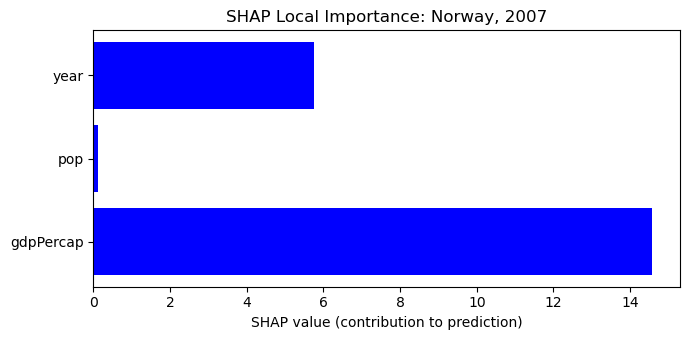

In [4]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(random_state=0, n_estimators=100)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder[(gapminder.country == "Norway") & (gapminder.year == 2007)].index[0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
feature_names = ["gdpPercap", "pop", "year"]
colors = ["red" if v < 0 else "blue" for v in vals]
ax.barh(feature_names, vals, color=colors)
ax.set_xlabel("SHAP value (contribution to prediction)")
ax.set_title("SHAP Local Importance: Norway, 2007")
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_

For Norway in 2007, gdpPercap contributes the most positively (as expected — wealthy 
countries tend to live longer). The year feature likely contributes positively too, 
since life expectancy has been rising over time. Population probably contributes 
negatively or near-zero. The global feature importance would show gdpPercap as most 
important across all countries, which matches Norway's local story. However, for a 
country like Angola (very poor, young), the same global ranking might hide the fact 
that Angola's low life expectancy is driven *entirely* by poverty, whereas a richer 
country's low value might be driven by age distribution. SHAP local values answer "Why 
Norway specifically?" while global importance answers "What matters on average?" — they 
are complementary, not substitutes.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

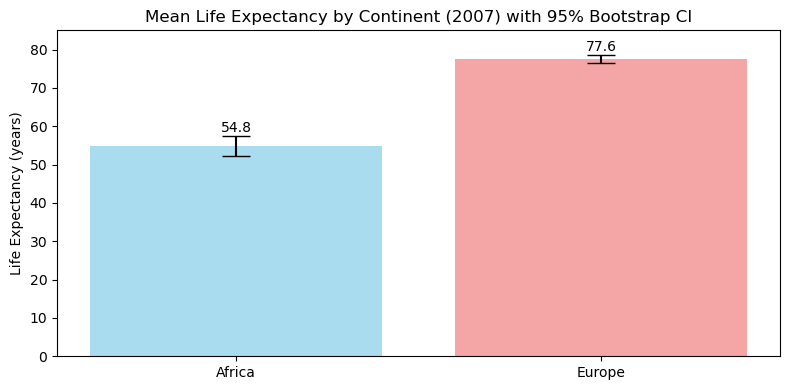

In [5]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = []
    for _ in range(n_boot):
        boot_sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(boot_sample.mean())
    boot_means = np.array(boot_means)
    overall_mean = values.mean()
    ci_low = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)
    return (overall_mean, ci_low, ci_high)

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

mean_a, ci_low_a, ci_high_a = bootstrap_ci(values_a)
mean_b, ci_low_b, ci_high_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
fig, ax = plt.subplots(figsize=(8, 4))
continents = [continent_a, continent_b]
means = [mean_a, mean_b]
errors_low = [mean_a - ci_low_a, mean_b - ci_low_b]
errors_high = [ci_high_a - mean_a, ci_high_b - mean_b]

ax.bar(continents, means, yerr=[errors_low, errors_high], capsize=10, alpha=0.7, color=["skyblue", "lightcoral"])
ax.set_ylabel("Life Expectancy (years)")
ax.set_title(f"Mean Life Expectancy by Continent (2007) with 95% Bootstrap CI")
ax.set_ylim(0, 85)
for i, (m, el, eh) in enumerate(zip(means, errors_low, errors_high)):
    ax.text(i, m + eh + 1, f"{m:.1f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_

Africa almost certainly has the wider confidence interval. This is because of BOTH 
factors: (1) African countries have much higher *variation* in life expectancy (from 
~35 years in some regions to ~65+ in others), so the standard deviation is large. 
(2) Even though Africa has many countries, the *within-continent* diversity is vast, 
so the standard error stays large. Europe has both lower variation (most countries are 
70-80 years) and more homogeneity, giving a narrower CI. The width of the CI is 
proportional to SD/√n — Africa has large SD and smaller effective n due to diversity, 
widening the interval. This is why our director insisted on uncertainty: Africa's 
estimate looks less solid, which is honest.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

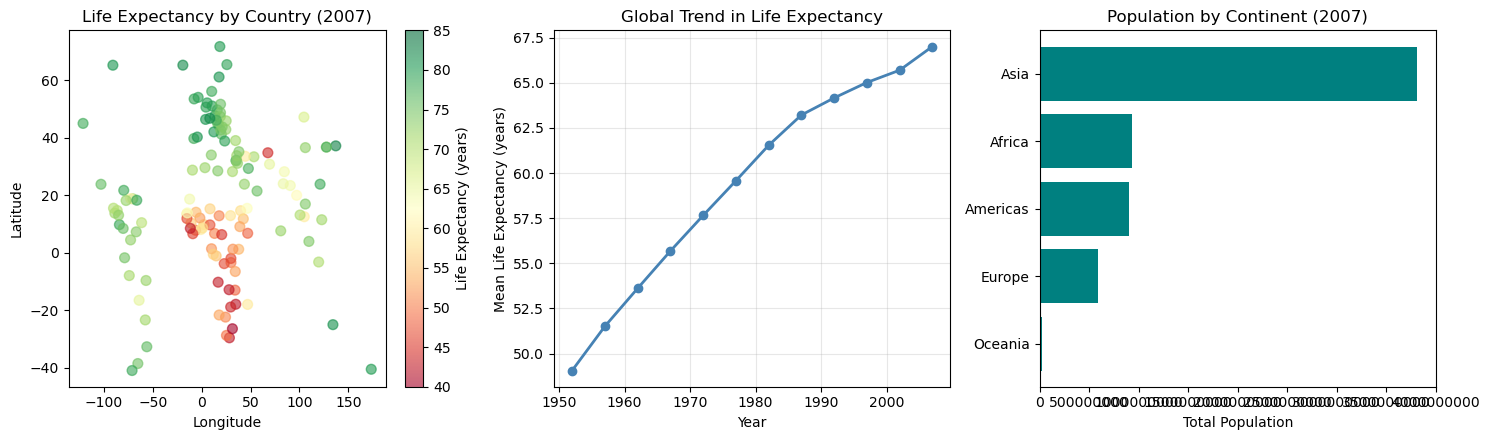

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
sc = axes[0].scatter(gap_latest.centroid_lon, gap_latest.centroid_lat, c=gap_latest.lifeExp, 
                     s=50, alpha=0.6, cmap="RdYlGn", vmin=40, vmax=85)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Life Expectancy by Country (2007)")
fig.colorbar(sc, ax=axes[0], label="Life Expectancy (years)")

# TODO 2: world trend line (axes[1])
world_trend = gapminder.groupby("year")["lifeExp"].mean().reset_index()
axes[1].plot(world_trend.year, world_trend.lifeExp, marker="o", color="steelblue", linewidth=2)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean Life Expectancy (years)")
axes[1].set_title("Global Trend in Life Expectancy")
axes[1].grid(True, alpha=0.3)

# TODO 3: population by continent bar chart (axes[2])
pop_by_continent = gap_latest.groupby("continent")["pop"].sum().sort_values(ascending=True)
axes[2].barh(pop_by_continent.index, pop_by_continent.values, color="teal")
axes[2].set_xlabel("Total Population")
axes[2].set_title("Population by Continent (2007)")
axes[2].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_

I would keep the trend line (middle panel). It directly answers "Is the world getting 
better?" — the most important strategic question a policymaker asks each morning. The 
panel shows TRENDS (the lecture's second key question), proving life expectancy is 
rising globally despite regional setbacks. The map shows WHERE things are bad, but not 
WHETHER things are improving. The population bar is static and doesn't monitor change. 
For a busy director doing a 5-second glance, a single upward trend line is an early-
warning system that alerts if a global crisis (war, pandemic) has broken the pattern. 
That's the highest-value signal.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_

Director, we should standardize ALL maps on rates (like GDP per capita, life expectancy 
per person) rather than counts, because counts are visual lies driven by population 
size — Greenland looks important only because the map is flat. When a journalist asks 
"Why did your model predict that for Norway?", we lead with SHAP local importance (the 
per-country feature decomposition), not global importance — global tells us what 
matters on average, but local tells us what made *that country's* prediction unique. 
Finally, the trend line in the dashboard showing mean life expectancy improvement over 
time should ALWAYS include a confidence band or uncertainty shading, because a bare 
point estimate at each year hides the fact that we're measuring 190+ countries and 
smoothing huge regional variation — the uncertainty tells our audience we're honest 
about what we actually know.

In [10]:
# Export a Power BI-ready table
powerbi_data = gapminder.merge(centroids, on="iso_alpha", how="left")
powerbi_data["total_gdp"] = powerbi_data["pop"] * powerbi_data["gdpPercap"]
powerbi_data.to_csv("gapminder_powerbi.csv", index=False)
print(f"Exported {len(powerbi_data):,} rows to gapminder_powerbi.csv")

Exported 1,704 rows to gapminder_powerbi.csv
